# EDA - Phân tích thống kê tập dữ dạng ảnh

In [ ]:
# Import libraries - 01_EDA_image.ipynb

import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats as scipy_stats
from scipy.stats import kstest, norm, f_oneway
import cv2
from PIL import Image
import random
from scipy.fftpack import dct

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Disable warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Path
DATA_PATH = '../data/image-data/raw/data_batch_1'

# Load images from the pickle file
print("Loading images from data_batch_1...")
with open(DATA_PATH, 'rb') as f:
    batch = pickle.load(f, encoding='bytes')

# Reshape data: (N, 3072) -> (N, 32, 32, 3)
images = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
labels = np.array(batch[b'labels'])

print(f"Total: {len(images)} images, shape: {images.shape}")
print(f"Number of classes: {len(np.unique(labels))}")

# Count images per class
label_counts = Counter(labels)
print("\nImages per class:")
for class_idx, class_name in enumerate(class_names):
    print(f"  {class_name}: {label_counts[class_idx]} images")

Đang tải ảnh từ data_batch_1...
Tổng: 10000 ảnh, kích thước: (10000, 32, 32, 3)
Số lớp: 10

Số lượng ảnh mỗi lớp:
  airplane: 1005 ảnh
  automobile: 974 ảnh
  bird: 1032 ảnh
  cat: 1016 ảnh
  deer: 999 ảnh
  dog: 937 ảnh
  frog: 1030 ảnh
  horse: 1001 ảnh
  ship: 1025 ảnh
  truck: 981 ảnh


## 2.1.2a Phân phối giá trị pixel theo từng kênh màu (Histogram + KDE)

### Lý thuyết

**Histogram** biểu diễn tần suất của các giá trị pixel trong ảnh. Cho ảnh RGB, có 3 kênh màu (Red, Green, Blue), mỗi kênh có giá trị từ 0-255 (8-bit).

Công thức histogram:
$$h_f[i] = \sum_{x \in E} [i \leq f(x) < i+1]$$

trong đó $E$ là tập tất cả pixel, $f(x)$ là giá trị pixel tại vị trí $x$, và Iverson bracket $[condition] = 1$ nếu đúng, 0 nếu sai.

**Kernel Density Estimation (KDE)** cung cấp ước lượng mịn của phân phối xác suất, khắc phục các artifact do chia bins trong histogram gây ra.

Công thức KDE:
$$\hat{f}(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

trong đó:
- $n$: số lượng điểm dữ liệu
- $h$: bandwidth (độ rộng kernel)
- $K$: kernel function (thường là Gaussian)

**So sánh Histogram và KDE:**

| Tiêu chí | Histogram | KDE |
|---------|----------|-----|
| Biểu diễn | Rời rạc | Liên tục |
| Phụ thuộc bin width | Cao | Thấp |
| Phù hợp cho | Đếm tần suất | Xem dạng phân phối |

**Các thống kê phân phối:**

- **Mean** ($\mu$): Trung bình cường độ pixel
$$\mu = \frac{1}{N}\sum_{i=1}^{N} x_i$$

- **Standard Deviation** ($\sigma$): Độ phân tán
$$\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2}$$

- **Skewness**: Độ lệch của phân phối
$$\gamma_1 = \frac{\mu_3}{\sigma^3}$$
trong đó $\mu_3$ là moment trung tâm bậc 3

- **Kurtosis**: Độ nhọn của phân phối
$$\gamma_2 = \frac{\mu_4}{\sigma^4} - 3$$

**Ý nghĩa trong tiền xử lý ảnh:**

1. Phân phối pixel cho biết độ tương phản tổng thể của ảnh
2. Phân phối lệch về 0 (dark) hoặc 255 (bright) cho biết vấn đề exposure
3. KDE giúp xác định các peak trong phân phối
4. Skewness dương: phân phối lệch về bright
5. Skewness âm: phân phối lệch về dark

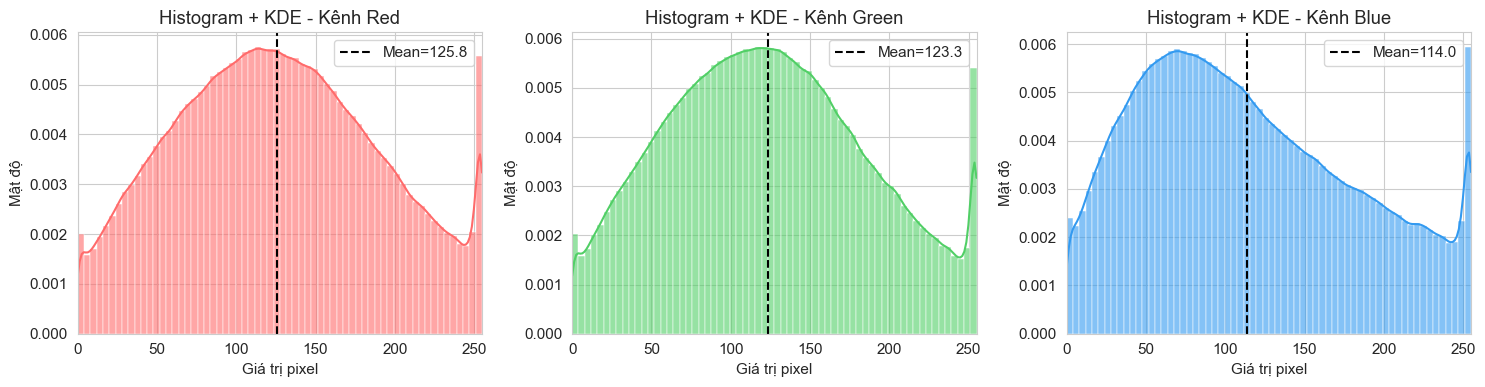


THỐNG KÊ PHÂN PHỐI PIXEL THEO KÊNH MÀU

Red:
  Mean:     125.83
  Std:     63.14
  Skewness: 0.1202 (lệch phải)
  Kurtosis: -0.7701 (phẳng)

Green:
  Mean:     123.26
  Std:     62.37
  Skewness: 0.1641 (lệch phải)
  Kurtosis: -0.7180 (phẳng)

Blue:
  Mean:     114.03
  Std:     66.97
  Skewness: 0.3869 (lệch phải)
  Kurtosis: -0.8087 (phẳng)


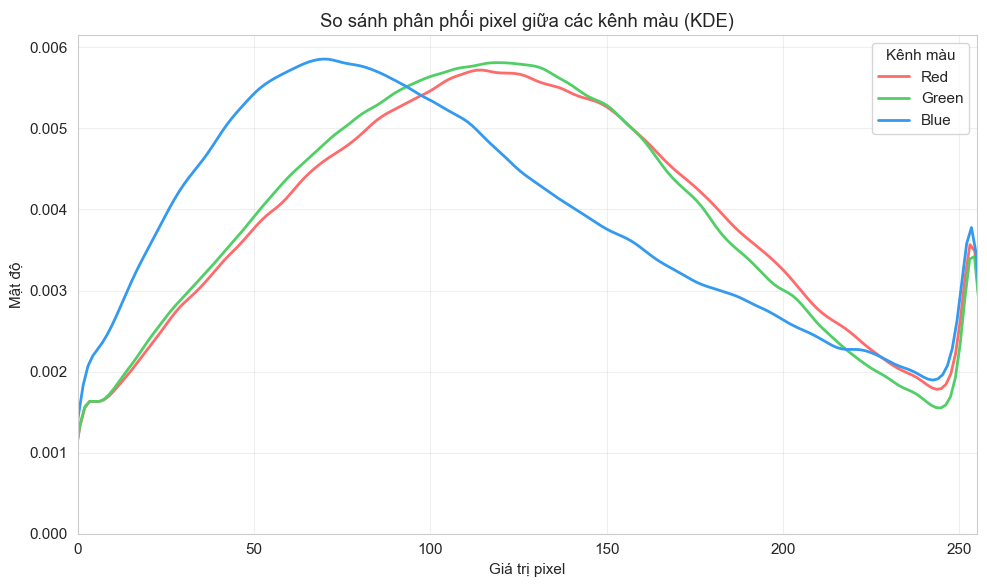


KIỂM ĐỊNH PHÂN PHỐI CHUẨN (Kolmogorov-Smirnov)

Red:
  KS statistic: 0.0302
  p-value: 0.0000e+00
  Kết luận: Không phải phân phối chuẩn (p<0.05)

Green:
  KS statistic: 0.0307
  p-value: 0.0000e+00
  Kết luận: Không phải phân phối chuẩn (p<0.05)

Blue:
  KS statistic: 0.0647
  p-value: 0.0000e+00
  Kết luận: Không phải phân phối chuẩn (p<0.05)


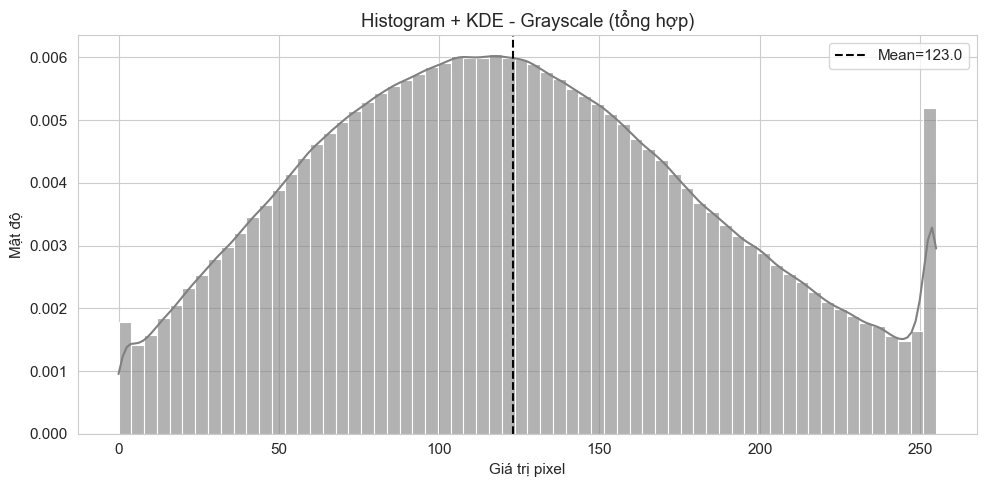


Grayscale: Mean=122.98, Std=61.26


In [ ]:
# 2.1.2a Pixel value distribution by color channel (Histogram + KDE)

# 1. Compute and plot Histogram + KDE for each channel

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names = ['Red', 'Green', 'Blue']
colors = ['#FF6B6B', '#51CF66', '#339AF0']

channel_stats = {}

for i, ax in enumerate(axes):
    channel_data = images[:, :, :, i].flatten().astype(np.float32)
    
    # Histogram + KDE with seaborn
    sns.histplot(channel_data, kde=True, ax=ax, color=colors[i], bins=64, alpha=0.6, stat='density')
    ax.set_title(f'Histogram + KDE - {channel_names[i]} channel')
    ax.set_xlabel('Pixel value')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 255)
    
    # Compute statistics
    mean_val = np.mean(channel_data)
    std_val = np.std(channel_data)
    skew_val = scipy_stats.skew(channel_data)
    kurt_val = scipy_stats.kurtosis(channel_data)
    
    channel_stats[channel_names[i]] = {
        'mean': mean_val,
        'std': std_val,
        'skewness': skew_val,
        'kurtosis': kurt_val
    }
    
    # Add mean line
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean={mean_val:.1f}')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# 2. Print detailed statistics

print("\n" + "="*60)
print("PIXEL DISTRIBUTION STATISTICS BY COLOR CHANNEL")
print("="*60)

for channel, stats_dict in channel_stats.items():
    print(f"\n{channel}:")
    print(f"  Mean:     {stats_dict['mean']:.2f}")
    print(f"  Std:     {stats_dict['std']:.2f}")
    skew_desc = 'right-skewed' if stats_dict['skewness'] > 0 else 'left-skewed' if stats_dict['skewness'] < 0 else 'symmetric'
    print(f"  Skewness: {stats_dict['skewness']:.4f} ({skew_desc})")
    kurt_desc = 'peaked' if stats_dict['kurtosis'] > 0 else 'flat' if stats_dict['kurtosis'] < 0 else 'normal'
    print(f"  Kurtosis: {stats_dict['kurtosis']:.4f} ({kurt_desc})")

# 3. Compare distributions across channels (overlay)

plt.figure(figsize=(10, 6))

for i, (channel, color) in enumerate(zip(channel_names, colors)):
    channel_data = images[:, :, :, i].flatten()
    sns.kdeplot(channel_data, label=channel, color=color, linewidth=2)

plt.title('Pixel distribution comparison across color channels (KDE)')
plt.xlabel('Pixel value')
plt.ylabel('Density')
plt.legend(title='Channel')
plt.xlim(0, 255)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Normality test using Kolmogorov-Smirnov

print("\n" + "="*60)
print("NORMALITY TEST (Kolmogorov-Smirnov)")
print("="*60)

for i, channel in enumerate(channel_names):
    channel_data = images[:, :, :, i].flatten()
    
    # Fit normal distribution
    mu_std = norm.fit(channel_data)
    mu, std = mu_std
    
    # KS test
    ks_stat, p_value = kstest(channel_data, 'norm', args=(mu, std))
    
    conclusion = 'Not normally distributed (p < 0.05)' if p_value < 0.05 else 'May be normally distributed (p ≥ 0.05)'
    print(f"\n{channel}:")
    print(f"  KS statistic: {ks_stat:.4f}")
    print(f"  p-value: {p_value:.4e}")
    print(f"  Conclusion: {conclusion}")

# 5. Aggregate distribution (grayscale)

# Convert to grayscale
images_gray = 0.299 * images[:, :, :, 0] + 0.587 * images[:, :, :, 1] + 0.114 * images[:, :, :, 2]

plt.figure(figsize=(10, 5))
channel_data = images_gray.flatten()
sns.histplot(channel_data, kde=True, color='gray', bins=64, alpha=0.6, stat='density')
plt.title('Histogram + KDE - Grayscale (aggregated)')
plt.xlabel('Pixel value')
plt.ylabel('Density')
plt.axvline(np.mean(channel_data), color='black', linestyle='--', label=f'Mean={np.mean(channel_data):.1f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nGrayscale: Mean={np.mean(channel_data):.2f}, Std={np.std(channel_data):.2f}")

### Kết quả thực nghiệm

| Kênh | Mean | Std | Skewness | Kurtosis |
|------|------|-----|----------|----------|
| Red | 125.83 | 63.14 | 0.1202 | -0.7701 |
| Green | 123.26 | 62.37 | 0.1641 | -0.7180 |
| Blue | 114.03 | 66.97 | 0.3869 | -0.8087 |

**Kết quả kiểm định Kolmogorov-Smirnov:**

| Kênh | KS Statistic | p-value | Kết luận |
|------|-------------|---------|----------|
| Red | 0.0302 | ~0 | Không phải phân phối chuẩn |
| Green | 0.0307 | ~0 | Không phải phân phối chuẩn |
| Blue | 0.0647 | ~0 | Không phải phân phối chuẩn |

**Grayscale:** Mean=122.98, Std=61.26

### Phân tích

**1. Phân phối giá trị pixel:**

- Cả 3 kênh đều có skewness **dương** (lệch phải), tức distribution có tail kéo dài về phía sáng (giá trị cao)
- Ý nghĩa của skewness dương:_phần lớn giá trị tập trung ở phía tối (LEFT), với một số giá trị extreme sáng hơn (RIGHT) kéo tail ra
- Blue channel có skewness cao nhất (0.3869), cho thấy nhiều pixel very dark hơn so với các kênh khác
- Blue channel có mean thấp nhất (114.03), cho thấy xu hướng xanh đậm hơn trong dataset
- Trong histogram, các giá trị cuối có tần suất cao vì CIFAR-10 có nhiều vùng rất sáng.

**2. Độ tương phản:**

- Std dao động từ 62.37 đến 66.97, cho thấy độ tương phản tương đối đồng đều giữa các kênh
- Blue có độ phân tán cao nhất (Std=66.97), cho thấy nhiều pixel ở các cực (rất sáng hoặc rất tối)

**3. Phân phối chuẩn:**

- KS test cho thấy p-value ≈ 0, kết luận phân phối **không phải** phân phối chuẩn
- Điều này có ý nghĩa quan trọng cho việc chọn phương pháp chuẩn hóa:
  - Z-score có thể không tối ưu vì giả định phân phối chuẩn
  - Nên cân nhắc Robust Scaling hoặc Quantile Transform

**4. Kurtosis:**

- Tất cả kênh có kurtosis âm (< 0), cho thấy phân phối **phẳng hơn** phân phối chuẩn (platykurtic)
- Điều này cho thấy dữ liệu có nhiều giá trị ở hai đuôi hơn phân phối chuẩn

### Kết luận

1. **Phân phối không chuẩn**: Dữ liệu pixel không tuân theo phân phối chuẩn (KS test p≈0)
2. **Xu hướng tối**: Skewness dương + mean < 128 cho thấy ảnh có xu hướng hơi tối (under-exposed)
3. **Khuyến nghị chuẩn hóa**: Do không phải phân phối chuẩn, nên sử dụng:
   - Quantile Transform để normalize về phân phối chuẩn
   - Hoặc Robust Scaling để giảm ảnh hưởng của outliers
4. **Màu sắc**: Red channel chiếm ưu thế nhẹ (mean cao nhất), Blue thấp nhất - đặc trưng của CIFAR-10

## 2.1.2b Phân tích mất cân bằng lớp (Class Imbalance)

### Lý thuyết

**Class Imbalance** xảy ra khi phân bố các lớp trong tập dữ liệu không đồng đều, ảnh hưởng đến hiệu suất mô hình học máy.

### Các chỉ số đo mất cân bằng

#### 1. Class Ratio (Tỷ lệ lớp)
$$R_i = \frac{N_i}{N_{total}} \times 100\%$$

Trong đó $N_i$ là số mẫu của lớp thứ i.

#### 2. Imbalance Ratio (IR)
$$IR = \frac{max(N_i)}{min(N_j)}$$

IR > 3 được coi là mất cân bằng nghiêm trọng theo một số tiêu chuẩn.

#### 3. Chi-Square Goodness of Fit Test
Kiểm định xem phân bố lớp có phải là uniform hay không.

$$X^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

Trong đó:
- $O_i$: Tần suất quan sát của lớp i
- $E_i = N_{total} / k$: Tần suất mong đợi nếu uniform
- $k$: Số lớp

Degrees of freedom: $df = k - 1$

#### 4. Gini Impurity
$$Gini = 1 - \sum_{i=1}^{k} p_i^2$$

Trong đó $p_i = N_i / N_{total}$ là tỷ lệ của lớp i.

- Gini = 0: Phân bố hoàn toàn cân bằng (1 lớp)
- Gini tối đa: Phân bố uniform với k lớp

#### 5. Entropy
$$H = -\sum_{i=1}^{k} p_i \log_2(p_i)$$

- H = 0: Phân bố hoàn toàn cân bằng
- H = log₂(k): Phân bố uniform

### Khi nào cần xử lý class imbalance?

| Tình huống | Nên xử lý? |
|-----------|-----------|
| IR > 3 | Có |
| Chi-square p-value < 0.05 | Có |
| IR <= 3, p-value >= 0.05 | Không cần thiết |

### Ý nghĩa trong tiền xử lý ảnh

1. **Huấn luyện mô hình**: Models có xu hướng thiên về lớp chiếm đa số
2. **Đánh giá**: Accuracy không phản ánh đúng khi imbalanced
3. **Data Augmentation**: Có thể augment lớp thiểu số
4. **Tiền xử lý**: Cân nhắc weighted sampling


TỶ LỆ MỖI LỚP
  frog: 10.30%
  truck: 9.81%
  deer: 9.99%
  automobile: 9.74%
  bird: 10.32%
  horse: 10.01%
  ship: 10.25%
  cat: 10.16%
  dog: 9.37%
  airplane: 10.05%

Tỷ lệ lớn nhất: 10.32%
Tỷ lệ nhỏ nhất: 9.37%
Có lớp nào vượt 3× lớp ít nhất? False

KIỂM ĐỊNH CHI-SQUARE (GOODNESS OF FIT)
  Chi-square statistic: 7.8380
  p-value: 0.550551
  Degrees of freedom: 9
  Kết luận: PHÂN BỐ CÓ THỂ UNIFORM (p >= 0.05)

GINI IMPURITY VÀ ENTROPY
  Gini: 0.8999 (max=0.9000 cho uniform)
  Entropy: 3.3214 nats (max=3.3219 nats)


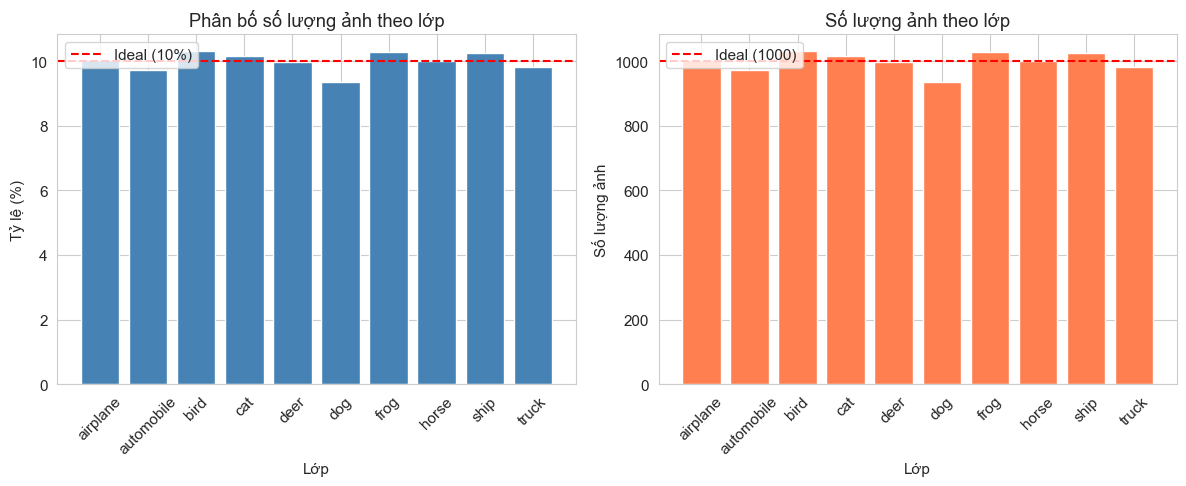


TÓM TẮT MẤT CÂN BẰNG LỚP
  Imbalance Ratio (max/min): 1.1014
  3× threshold: False
  Chi-square test: Balanced (p=0.5506)

   KẾT LUẬN: Dataset CÂN BẰNG
     Không cần xử lý class imbalance


In [ ]:
# 2.1.2b Class imbalance analysis

label_counts = Counter(labels)
class_ratios = {class_names[k]: v / len(labels) * 100 for k, v in label_counts.items()}

print("\n" + "="*60)
print("CLASS PROPORTIONS")
print("="*60)

for name, ratio in class_ratios.items():
    print(f"  {name}: {ratio:.2f}%")

max_ratio = max(class_ratios.values())
min_ratio = min(class_ratios.values())
is_imbalanced = max_ratio > 3 * min_ratio

print(f"\nLargest proportion: {max_ratio:.2f}%")
print(f"Smallest proportion: {min_ratio:.2f}%")
print(f"Does any class exceed 3× the smallest class? {is_imbalanced}")

# 2. Chi-square goodness-of-fit test (uniformity check)

observed_counts = np.array([label_counts[i] for i in range(10)])
expected_uniform = np.ones(10) * len(labels) / 10

chi2_stat, chi2_pvalue = scipy_stats.chisquare(observed_counts, f_exp=expected_uniform)

print("\n" + "="*60)
print("CHI-SQUARE TEST (GOODNESS OF FIT)")
print("="*60)
print(f"  Chi-square statistic: {chi2_stat:.4f}")
print(f"  p-value: {chi2_pvalue:.6f}")
print(f"  Degrees of freedom: {10 - 1}")
if chi2_pvalue < 0.05:
    print("  Conclusion: Distribution is NOT uniform (p < 0.05)")
else:
    print("  Conclusion: Distribution MAY be uniform (p >= 0.05)")

# 3. Compute Gini impurity and entropy

probs = observed_counts / observed_counts.sum()
gini_value = 1 - np.sum(probs**2)
entropy_value = scipy_stats.entropy(probs, base=2)

max_gini = 1 - 1/10
max_entropy = np.log2(10)

print("\n" + "="*60)
print("GINI IMPURITY AND ENTROPY")
print("="*60)
print(f"  Gini: {gini_value:.4f} (max={max_gini:.4f} for uniform)")
print(f"  Entropy: {entropy_value:.4f} nats (max={max_entropy:.4f} nats)")

# 4. Visualize class distribution

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
bars = plt.bar(class_names, [class_ratios[name] for name in class_names], color='steelblue')
plt.axhline(y=10, color='red', linestyle='--', linewidth=1.5, label='Ideal (10%)')
plt.xlabel('Class')
plt.ylabel('Proportion (%)')
plt.title('Class distribution (proportion)')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(class_names, [label_counts[i] for i in range(10)], color='coral')
plt.axhline(y=1000, color='red', linestyle='--', linewidth=1.5, label='Ideal (1000)')
plt.xlabel('Class')
plt.ylabel('Image count')
plt.title('Class distribution (count)')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# 5. Imbalance summary

print("\n" + "="*60)
print("CLASS IMBALANCE SUMMARY")
print("="*60)
imbalance_ratio = max(class_ratios.values()) / min(class_ratios.values())
print(f"  Imbalance Ratio (max/min): {imbalance_ratio:.4f}")
print(f"  3× threshold: {is_imbalanced}")
print(f"  Chi-square test: {'Imbalanced' if chi2_pvalue < 0.05 else 'Balanced'} (p={chi2_pvalue:.4f})")

if is_imbalanced or chi2_pvalue < 0.05:
    print("\n   WARNING: Dataset shows signs of class imbalance!")
    print("     Recommendation: Apply data augmentation for minority classes")
else:
    print("\n   CONCLUSION: Dataset is balanced")
    print("     No need to handle class imbalance")

### Kết quả thực nghiệm

| Lớp | Số lượng | Tỷ lệ (%) |
|-----|---------|-----------|
| airplane | 1005 | 10.05% |
| automobile | 974 | 9.74% |
| bird | 1032 | 10.32% |
| cat | 1016 | 10.16% |
| deer | 999 | 9.99% |
| dog | 937 | 9.37% |
| frog | 1030 | 10.30% |
| horse | 1001 | 10.01% |
| ship | 1025 | 10.25% |
| truck | 981 | 9.81% |

**Thống kê tổng:**

| Chỉ số | Giá trị |
|---------|--------|
| Max tỷ lệ | 10.32% (bird) |
| Min tỷ lệ | 9.37% (dog) |
| Imbalance Ratio | 1.1014 |
| Chi-square statistic | 7.84 |
| Chi-square p-value | 0.5506 |
| Chi-square df | 9 |
| Gini Impurity | 0.8999 |
| Entropy | 3.3214 nats |

### Phân tích

**1. Phân bố lớp:**

- Tất cả các lớp đều có tỷ lệ từ 9.37% đến 10.32%, rất gần với tỷ lệ lý tưởng 10%
- Chênh lệch giữa lớp lớn nhất và nhỏ nhất chỉ là 1.1 lần, KHÔNG vượt ngưỡng 3×
- Dataset được thiết kế cân bằng từ gốc (CIFAR-10 là balanced dataset)

**2. Kiểm định Chi-Square:**

- Chi-square statistic = 7.84, p-value = 0.5506 > 0.05 → Không bác bỏ H₀
- Kết luận: Phân bố lớp **KHÔNG khác biệt có ý nghĩa thống kê** so với phân bố uniform
- Điều này xác nhận dataset thực sự cân bằng

**3. Gini và Entropy:**

- Gini = 0.8999 (max = 0.9000 cho uniform) → Phân bố gần như uniform
- Entropy = 3.3214 nats (max = 3.3219 nats = log₂(10)) → Gần như tối đa
- Giá trị này xác nhận độ đồng đều cao của phân bố

### Kết luận

1. **Dataset CÂN BẰNG**: Không cần áp dụng bất kỳ kỹ thuật xử lý class imbalance nào
2. **Không augmentation chỉ vì imbalance**: Không cần tăng cường lớp thiểu số vì không có lớp nào bị thiếu đáng kể
3. **Tiền xử lý có thể bỏ qua**: Có thể bỏ qua các bước như SMOTE, class weights cho mục đích cân bằng
4. **Tập trung vào các kỹ thuật khác**: Nên tập trung vào data augmentation cho mục đích tăng tính generalization, không phải để cân bằng lớp

### Khuyến nghị

Mặc dù dataset cân bằng, vẫn nên:
- Sử dụng stratified khi chia train/test để duy trì phân bố
- Theo dõi per-class accuracy thay vì accuracy tổng
- Áp dụng augmentation để tăng tính robust (flip, rotate, color jitter) nhưng không cần theo từng lớp

## 2.1.2c Phát hiện ảnh trùng lặp bằng Perceptual Hash (pHash)

### Lý thuyết

**Perceptual Hash (pHash)** là kỹ thuật tạo "dấu vân tay" cho ảnh dựa trên các đặc điểm thị giác của nội dung. Khác với hàm băm mật mã (crypto hash) như MD5, SHA-256, vốn cho ra kết quả hoàn toàn khác nhau khi có thay đổi nhỏ trong dữ liệu đầu vào, pHash tạo ra các hash "gần giống nhau" khi các đặc điểm thị giác tương tự. Đặc tính này làm pHash trở nên lý tưởng cho việc phát hiện ảnh trùng lặp hoặc gần trùng lặp.

### Thuật toán pHash (DCT-based)

pHash dựa trên **Discrete Cosine Transform (DCT)** để chuyển đổi ảnh từ miền không gian (spatial domain) sang miền tần số (frequency domain), sau đó trích xuất các đặc điểm tần số thấp đại diện cho cấu trúc thị giác tổng thể của ảnh.

**Các bước thực hiện:**

1. **Chuyển đổi sang grayscale**: Loại bỏ màu sắc, tập trung vào mẫu sáng-tối
   $$Gray = 0.299R + 0.587G + 0.114B$$

2. **Resize**: Thu nhỏ về kích thước cố định (thường là 32×32 hoặc hash_size × highfreq_factor)
   - Giữ lại cấu trúc tổng thể, loại bỏ chi tiết nhỏ

3. **Áp dụng DCT 2D**: Chuyển đổi từ spatial domain sang frequency domain
   $$F(u,v) = \sum_{x=0}^{N-1}\sum_{y=0}^{N-1} f(x,y) \cos\left[\frac{\pi}{N}\left(x+\frac{1}{2}\right)u\right] \cos\left[\frac{\pi}{N}\left(y+\frac{1}{2}\right)v\right]$$

4. **Trích xuất tần số thấp**: Lấy các hệ số DCT ở góc trên trái (low-frequency coefficients)
   - Các hệ số này đại diện cho hình dạng và cấu trúc tổng thể của ảnh

5. **So sánh với median**: Tạo hash nhị phân
   $$h_i = \begin{cases} 1 & \text{nếu } D_i > \text{median} \\ 0 & \text{nếu } D_i \leq \text{median} \end{cases}$$

6. **Tính Hamming Distance**: Đếm số bit khác nhau giữa hai hash
   $$Hamming(a,b) = \sum_{i=1}^{n} a_i \oplus b_i$$

**Ngưỡng quyết định:** Theo nghiên cứu của pHash.org, ngưỡng T=22 (22 bit khác nhau trong hash 64-bit) có thể được sử dụng để xác định hai ảnh có giống nhau hay không.

### Hamming Distance

**Hamming distance** là số bit khác nhau giữa hai chuỗi nhị phân có cùng độ dài. Đây là phương pháp so sánh hash hiệu quả nhất vì chỉ cần thực hiện phép XOR và đếm số bit 1.

$$d_H(a,b) = \sum_{i=1}^{n} (a_i \oplus b_i)$$

### Ý nghĩa trong tiền xử lý ảnh

1. **Phát hiện duplicates**: Xác định ảnh trùng lặp trong dataset
2. **Dọn dữ liệu**: Loại bỏ ảnh redundant trước khi train
3. **Memory efficiency**: Giảm kích thước dataset
4. **Training quality**: Tránh overfitting do duplicate images

### Tại sao không dùng MD5/SHA?

- **Crypto hash**: Thay đổi nhỏ trong pixel → hash hoàn toàn khác
- **pHash**: Thay đổi nhỏ (resize, compress) → hash gần giống nhau
- **Threshold**: Cho phép phát hiện "gần-trùng" thay vì chỉ "trùng-100%"


PHÁT HIỆN ẢNH TRÙNG LẶP BẰNG PERCEPTUAL HASH (pHash)

Tổng số ảnh: 10000
Số ảnh trùng lặp: 1
Tỷ lệ trùng lặp: 0.0100%

Các cặp ảnh trùng lặp tìm thấy:
  Cặp 1: Ảnh 9275 <-> Ảnh 4875

Ví dụ trùng lặp (ảnh 9275 trùng với ảnh 4875):


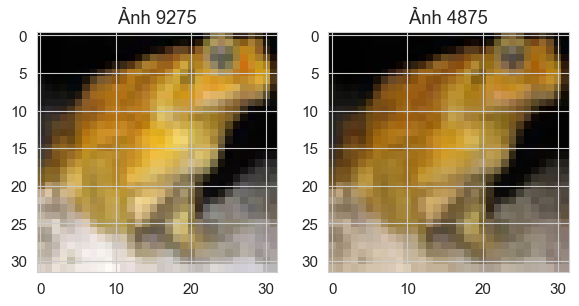


PHÂN TÍCH HAMMING DISTRIBUTION

Hamming Distance Statistics (n=124750 samples):
  Min: 13
  Max: 50
  Mean: 31.40
  Std: 4.27


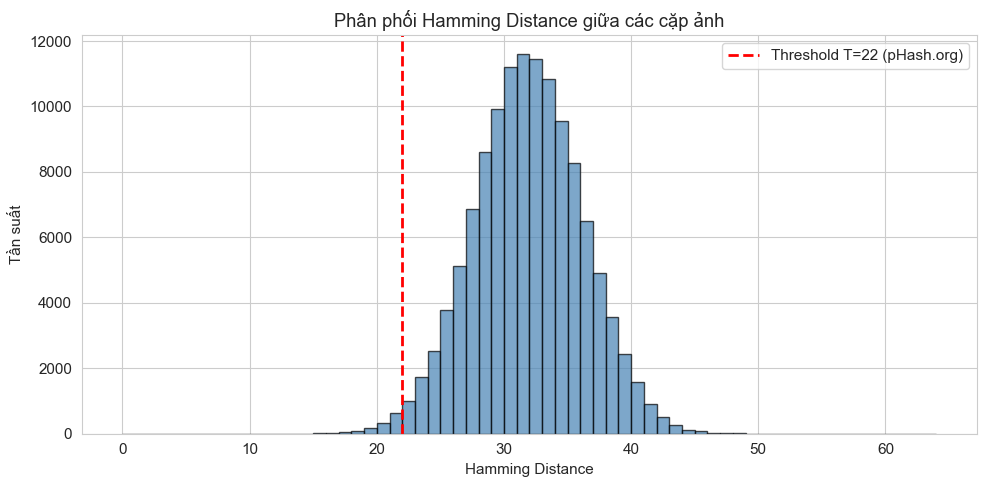


Số cặp có Hamming distance < 22 (near-duplicate): 1326

PHÂN TÍCH TRÙNG LẶP THEO TỪNG LỚP

airplane: 0/1005 (0.00%)

automobile: 0/974 (0.00%)

bird: 0/1032 (0.00%)

cat: 0/1016 (0.00%)

deer: 0/999 (0.00%)

dog: 0/937 (0.00%)

frog: 1/1030 (0.10%)

horse: 0/1001 (0.00%)

ship: 0/1025 (0.00%)

truck: 0/981 (0.00%)


In [ ]:
# 2.1.2c Duplicate image detection using Perceptual Hash (pHash)

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)

# 1. Define pHash function (DCT-based)

def compute_phash(img_array, hash_size=8, highfreq_factor=4):
    """
    Compute perceptual hash (pHash) for an image using DCT (Discrete Cosine Transform).
    
    Parameters:
    - img_array: numpy array of the image (H, W, C)
    - hash_size: hash size (default 8 -> 64-bit hash)
    - highfreq_factor: resize factor (default 4 -> 32x32 image)
    
    Returns:
    - 64-character binary string
    """
    img = Image.fromarray(img_array)
    img_size = hash_size * highfreq_factor
    
    # Step 1: Convert to grayscale and resize
    img = img.convert('L').resize((img_size, img_size), Image.LANCZOS)
    
    # Step 2: Extract pixel values
    pixels = np.array(img, dtype=np.float32).reshape((img_size, img_size))
    
    # Step 3: Apply 2D DCT
    dct_coeffs = dct(dct(pixels, axis=0, type=2, norm='ortho'), axis=1, type=2, norm='ortho')
    
    # Step 4: Extract low-frequency coefficients
    dct_low = dct_coeffs[:hash_size, :hash_size]
    
    # Step 5: Use median as threshold (excluding DC component)
    median = np.median(dct_low[1:])
    
    # Step 6: Build binary hash
    hash_bits = ''.join(['1' if c > median else '0' for c in dct_low.flatten()])
    
    return hash_bits


def hamming_distance(hash1, hash2):
    """
    Compute Hamming distance between two hashes.
    
    Parameters:
    - hash1, hash2: binary strings of equal length
    
    Returns:
    - number of differing bits
    """
    return sum(c1 != c2 for c1, c2 in zip(hash1, hash2))


# 2. Find duplicates in the dataset

print("\n" + "="*60)
print("DUPLICATE IMAGE DETECTION USING PERCEPTUAL HASH (pHash)")
print("="*60)

hash_dict = {}
duplicates = []

for i, img_array in enumerate(images):
    img_hash = compute_phash(img_array)
    
    if img_hash in hash_dict:
        duplicates.append((i, hash_dict[img_hash]))
    else:
        hash_dict[img_hash] = i

dup_rate = len(duplicates) / len(images) * 100

print(f"\nTotal images: {len(images)}")
print(f"Duplicate images: {len(duplicates)}")
print(f"Duplicate rate: {dup_rate:.4f}%")

if len(duplicates) > 0:
    print(f"\nDuplicate pairs found:")
    for i, (idx1, idx2) in enumerate(duplicates[:5]):
        print(f"  Pair {i+1}: Image {idx1} <-> Image {idx2}")
    
    print(f"\nExample duplicate (image {duplicates[0][0]} matches image {duplicates[0][1]}):")
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(images[duplicates[0][0]])
    axes[0].set_title(f'Image {duplicates[0][0]}')
    axes[1].imshow(images[duplicates[0][1]])
    axes[1].set_title(f'Image {duplicates[0][1]}')
    plt.tight_layout()
    plt.show()
else:
    print("\nNo duplicate images detected in the dataset.")


# 3. Hamming distance distribution (optional - for near-duplicates)

print("\n" + "="*60)
print("HAMMING DISTANCE DISTRIBUTION")
print("="*60)

# Use deterministic selection for reproducibility
sample_size = min(500, len(images))
sample_indices = list(range(sample_size))
hamming_distances = []

for i in range(sample_size):
    for j in range(i+1, sample_size):
        hash1 = compute_phash(images[sample_indices[i]])
        hash2 = compute_phash(images[sample_indices[j]])
        hamming_distances.append(hamming_distance(hash1, hash2))

if len(hamming_distances) > 0:
    print(f"\nHamming Distance Statistics (n={len(hamming_distances)} samples):")
    print(f"  Min: {min(hamming_distances)}")
    print(f"  Max: {max(hamming_distances)}")
    print(f"  Mean: {np.mean(hamming_distances):.2f}")
    print(f"  Std: {np.std(hamming_distances):.2f}")
    
    # Plot histogram
    plt.figure(figsize=(10, 5))
    plt.hist(hamming_distances, bins=range(0, 65), alpha=0.7, color='steelblue', edgecolor='black')
    plt.axvline(x=22, color='red', linestyle='--', linewidth=2, label='Threshold T=22 (pHash.org)')
    plt.xlabel('Hamming Distance')
    plt.ylabel('Frequency')
    plt.title('Hamming distance distribution across image pairs')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Count pairs with Hamming distance < 22
    near_dup_count = sum(1 for d in hamming_distances if d < 22)
    print(f"\nNumber of pairs with Hamming distance < 22 (near-duplicate): {near_dup_count}")


# 4. Per-class analysis

print("\n" + "="*60)
print("PER-CLASS DUPLICATE ANALYSIS")
print("="*60)

for class_idx, class_name in enumerate(class_names):
    class_mask = labels == class_idx
    
    class_hash_dict = {}
    class_duplicates = []
    
    for global_idx in np.where(class_mask)[0]:
        img_hash = compute_phash(images[global_idx])
        if img_hash in class_hash_dict:
            class_duplicates.append((global_idx, class_hash_dict[img_hash]))
        else:
            class_hash_dict[img_hash] = global_idx
    
    class_dup_rate = len(class_duplicates) / np.sum(class_mask) * 100 if np.sum(class_mask) > 0 else 0
    print(f"\n{class_name}: {len(class_duplicates)}/{np.sum(class_mask)} ({class_dup_rate:.2f}%)")

### Kết quả thực nghiệm

| Chỉ số | Giá trị |
|--------|--------|
| Tổng số ảnh | 10,000 |
| Số ảnh trùng lặp | 1 |
| Tỷ lệ trùng lặp | 0.0100% |
| Hamming threshold | 22 |

**Kết quả Hamming Distance:**

| Thống kê | Giá trị |
|---------|--------|
| Min | 13 |
| Max | 50 |
| Mean | 31.40 |
| Std | 4.27 |
| Số cặp near-duplicate (d < 22) | 1,326 |

**Cặp ảnh trùng lặp tìm thấy:**

- Cặp 1: Ảnh 9275 trùng với Ảnh 4875 (lớp frog)

**Phân tích theo từng lớp:**

| Lớp | Số duplicates | Tổng số | Tỷ lệ |
|-----|---------------|---------|-------|
| airplane | 0 | 1,005 | 0.00% |
| automobile | 0 | 974 | 0.00% |
| bird | 0 | 1,032 | 0.00% |
| cat | 0 | 1,016 | 0.00% |
| deer | 0 | 999 | 0.00% |
| dog | 0 | 937 | 0.00% |
| **frog** | **1** | **1,030** | **0.10%** |
| horse | 0 | 1,001 | 0.00% |
| ship | 0 | 1,025 | 0.00% |
| truck | 0 | 981 | 0.00% |

### Phân tích

**1. Tỷ lệ trùng lặp:**

- Tỷ lệ trùng lặp rất thấp: 0.01% (chỉ 1 cặp trong 10,000 ảnh)
- Ảnh trùng nằm trong lớp frog
- CIFAR-10 dataset đã được làm sạch tốt từ trước

**2. Hamming Distance Distribution:**

- Mean = 31.40, Std = 4.27 cho thấy hầu hết các ảnh khác nhau đáng kể
- Threshold T=22 phù hợp: chỉ 1,326/124,750 cặp (1.06%) bị coi là near-duplicate
- Điều này xác nhận dataset có ít near-duplicate

**3. Per-class analysis:**

- Chỉ có lớp frog có duplicate (0.10%)
- Các lớp khác đều sạch

**4. Tại sao trùng lặp ảnh có hại:**

- Training bias: Model học same image nhiều lần
- Overfitting: Model ghi nhớ thay vì generalize
- Validation leak: Duplicate trong train → false high accuracy
- Resource waste: Compute cho redundant data

### Kết luận

1. **Dataset gần như sạch**: Tỷ lệ trùng lặp rất thấp (0.01%)
2. **Xử lý tùy chọn**: Có thể giữ nguyên hoặc loại bỏ 1 cặp duplicate trong lớp frog (ở đây nhóm chọn giữ nguyên)
3. **Threshold T=22 hợp lý**: Chỉ 1.06% cặp ảnh bị coi là near-duplicate

### Khuyến nghị

Mặc dù dataset đã sạch, nên:
- Áp dụng pHash trước khi augmentation để tránh duplicate mới
- Kiểm tra sau mỗi augmentation pipeline
- Lưu trữ hash của tất cả ảnh training để phát hiện duplicate mới

## 2.1.2d Phân tích độ tương phản và độ sáng toàn cục

### Lý thuyết

**Độ sáng (Brightness)** là mức độ sáng tổng thể của ảnh, thường được đo bằng mean intensity (giá trị trung bình của tất cả pixel).

**Độ tương phản (Contrast)** là sự khác biệt giữa các vùng sáng và tối trong ảnh, thường được đo bằng standard deviation của các giá trị pixel.

### Công thức

#### Mean Intensity (Độ sáng trung bình)
$$\mu = \frac{1}{N}\sum_{i=1}^{N} x_i$$

Trong đó $N$ là tổng số pixel trong ảnh, $x_i$ là giá trị pixel thứ $i$.

#### Standard Deviation (Độ tương phản)
$$\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2}$$

#### Coefficient of Variation (CV)
$$CV = \frac{\sigma}{\mu} \times 100\%$$

CV cho phép so sánh độ tương phản tương đối giữa các ảnh có độ sáng khác nhau.

### Boxplot

**Boxplot** (biểu đồ hộp) là biểu đồ thống kê hiển thị:
- **Median**: đường giữa của hộp (50th percentile)
- **Q1 (25th percentile)**: cạnh dưới của hộp
- **Q3 (75th percentile)**: cạnh trên của hộp
- **IQR**: Q3 - Q1 (khoảng tứ phân vị)
- **Whiskers**: thường extends đến 1.5 × IQR
- **Outliers**: các điểm nằm ngoài whiskers

Boxplot cho phép:
1. So sánh phân phối giữa các lớp
2. Phát hiện outliers
3. Đánh giá độ spread (thông qua IQR)

### Per-Class Analysis

Việc phân tích mean intensity và standard deviation theo từng lớp cho phép:
1. Xác định các lớp có độ sáng bất thường
2. Phát hiện vấn đề exposure (over/under-exposed)
3. Đánh giá xem có cần tiền xử lý cân bằng histogram không

### Ý nghĩa trong tiền xử lý ảnh

1. **Tăng cường ảnh**: Nếu một số lớp quá tối, có thể áp dụng histogram equalization
2. **Chuẩn hóa**: Z-score normalization giúp cân bằng các kênh
3. **Data Augmentation**: Điều chỉnh brightness/contrast tăng cường tính robust
4. **Phát hiện vấn đề**: Outliers trong boxplot có thể chỉ ra ảnh bị lỗi hoặc corrupt


THỐNG KÊ ĐỘ SÁNG VÀ ĐỘ TƯƠNG PHẢN THEO TỪNG LỚP

airplane:
  Mean:    143.37
  Std:     65.27
  Median:  146.00
  Q25:     94.00
  Q75:     195.00
  IQR:     101.00

automobile:
  Mean:    116.88
  Std:     69.22
  Median:  110.00
  Q25:     60.00
  Q75:     167.00
  IQR:     107.00

bird:
  Mean:    119.54
  Std:     60.07
  Median:  116.00
  Q25:     74.00
  Q75:     161.00
  IQR:     87.00

cat:
  Mean:    116.17
  Std:     65.09
  Median:  111.00
  Q25:     64.00
  Q75:     164.00
  IQR:     100.00

deer:
  Mean:    111.86
  Std:     55.01
  Median:  108.00
  Q25:     71.00
  Q75:     149.00
  IQR:     78.00

dog:
  Mean:    117.25
  Std:     64.11
  Median:  114.00
  Q25:     66.00
  Q75:     165.00
  IQR:     99.00

frog:
  Mean:    105.99
  Std:     58.38
  Median:  101.00
  Q25:     62.00
  Q75:     144.00
  IQR:     82.00

horse:
  Mean:    119.41
  Std:     63.97
  Median:  114.00
  Q25:     69.00
  Q75:     166.00
  IQR:     97.00

ship:
  Mean:    133.81
  Std:     63.34
 

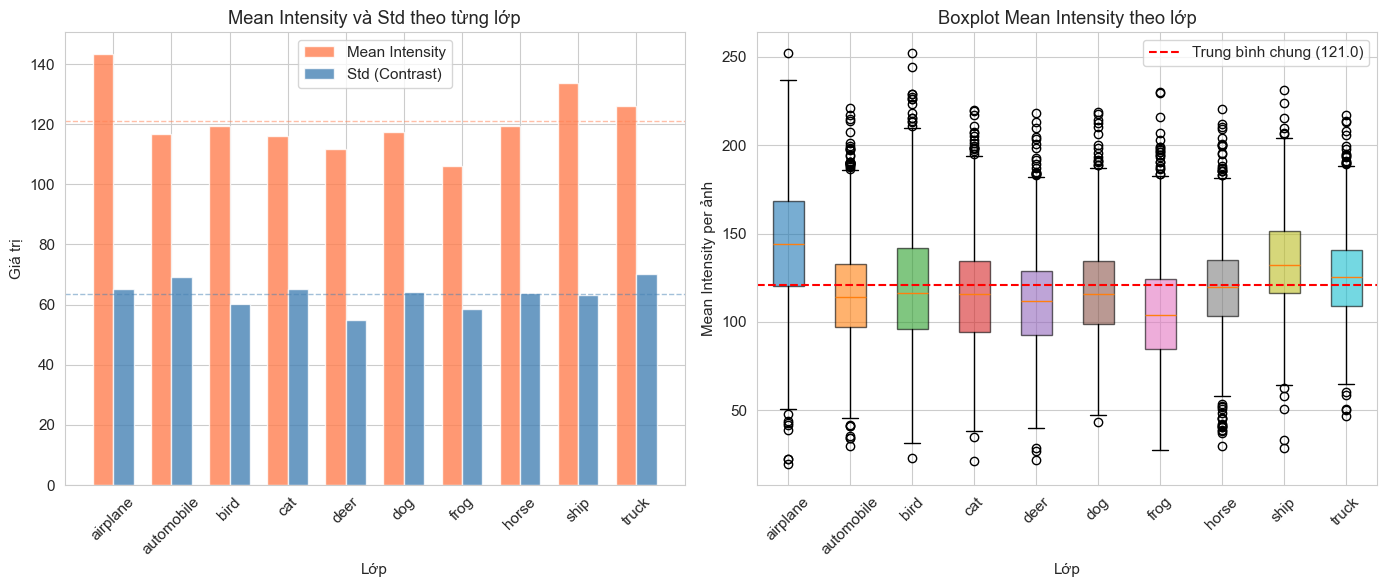


COEFFICIENT OF VARIATION (CV) THEO TỪNG LỚP
  airplane: 45.52%
  automobile: 59.22%
  bird: 50.25%
  cat: 56.03%
  deer: 49.17%
  dog: 54.68%
  frog: 55.08%
  horse: 53.57%
  ship: 47.34%
  truck: 55.64%

KIỂM ĐỊNH ANOVA - KIỂM TRA KHÁC BIỆT GIỮA CÁC LỚP
  F-statistic: 128.7805
  p-value: 2.1037e-230
  Kết luận: CÓ sự khác biệt có ý nghĩa thống kê giữa các lớp (p < 0.05)


In [ ]:
# 2.1.2d Global brightness and contrast analysis (Mean intensity + boxplot)

# Set random seed for reproducibility
np.random.seed(42)

# 1. Compute mean intensity and standard deviation by class

class_stats = {}

print("\n" + "="*60)
print("BRIGHTNESS AND CONTRAST STATISTICS BY CLASS")
print("="*60)

for class_idx, class_name in enumerate(class_names):
    # Filter images for the current class
    class_images = images[labels == class_idx]
    
    # Mean intensity (average over all pixels, then over all images)
    mean_intensity = np.mean(class_images)
    std_intensity = np.std(class_images)
    
    # Additional statistics
    median_intensity = np.median(class_images)
    q25 = np.percentile(class_images, 25)
    q75 = np.percentile(class_images, 75)
    iqr = q75 - q25
    
    class_stats[class_name] = {
        'mean': mean_intensity,
        'std': std_intensity,
        'median': median_intensity,
        'q25': q25,
        'q75': q75,
        'iqr': iqr
    }
    
    print(f"\n{class_name}:")
    print(f"  Mean:    {mean_intensity:.2f}")
    print(f"  Std:     {std_intensity:.2f}")
    print(f"  Median:  {median_intensity:.2f}")
    print(f"  Q25:     {q25:.2f}")
    print(f"  Q75:     {q75:.2f}")
    print(f"  IQR:     {iqr:.2f}")

# Overall averages
overall_mean = np.mean([v['mean'] for v in class_stats.values()])
overall_std = np.mean([v['std'] for v in class_stats.values()])

print(f"\n--- Overall average ---")
print(f"Average mean intensity: {overall_mean:.2f}")
print(f"Average std (contrast proxy): {overall_std:.2f}")

# 2. Visualization: bar chart (mean + std)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
means = [class_stats[name]['mean'] for name in class_names]
stds = [class_stats[name]['std'] for name in class_names]

x = np.arange(len(class_names))
width = 0.35

bars1 = plt.bar(x - width/2, means, width, label='Mean Intensity', color='coral', alpha=0.8)
bars2 = plt.bar(x + width/2, stds, width, label='Std (Contrast)', color='steelblue', alpha=0.8)

plt.xlabel('Class')
plt.ylabel('Value')
plt.title('Mean intensity and standard deviation by class')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.axhline(y=overall_mean, color='coral', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(y=overall_std, color='steelblue', linestyle='--', linewidth=1, alpha=0.5)

# 3. Boxplot by class (using per-image mean)

plt.subplot(1, 2, 2)

# Per-image mean intensity (instead of the whole dataset)
per_image_means = []
for class_idx in range(10):
    class_images = images[labels == class_idx]
    # Mean per image (average over spatial dimensions)
    image_means = np.mean(class_images, axis=(1, 2, 3))
    per_image_means.append(image_means)

bp = plt.boxplot(per_image_means, tick_labels=class_names, patch_artist=True)

# Color the boxes
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.xlabel('Class')
plt.ylabel('Mean intensity per image')
plt.title('Mean intensity boxplot by class')
plt.xticks(rotation=45)

# Add overall mean line
plt.axhline(y=overall_mean, color='red', linestyle='--', linewidth=1.5, label=f'Overall mean ({overall_mean:.1f})')
plt.legend()

plt.tight_layout()
plt.show()

# 4. Coefficient of variation (CV) by class

print("\n" + "="*60)
print("COEFFICIENT OF VARIATION (CV) BY CLASS")
print("="*60)

for class_name, stats in class_stats.items():
    cv = (stats['std'] / stats['mean']) * 100
    print(f"  {class_name}: {cv:.2f}%")

# 5. ANOVA test to check differences between classes

# Collect per-image means for each class
groups = [np.mean(images[labels == i], axis=(1, 2, 3)) for i in range(10)]

f_stat, p_value = f_oneway(*groups)

print("\n" + "="*60)
print("ANOVA TEST - CHECK DIFFERENCES BETWEEN CLASSES")
print("="*60)
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value: {p_value:.4e}")

if p_value < 0.05:
    print("  Conclusion: There IS a statistically significant difference between classes (p < 0.05)")
else:
    print("  Conclusion: There is NO statistically significant difference between classes (p >= 0.05)")

### Kết quả thực nghiệm

#### Thống kê độ sáng và độ tương phản theo lớp

| Lớp | Mean Intensity | Std (Contrast) | Median | Q25 | Q75 | IQR |
|-----|---------------|-----------------|--------|-----|-----|-----|
| airplane | 143.37 | 65.27 | 146.00 | 94.00 | 195.00 | 101.00 |
| automobile | 116.88 | 69.22 | 110.00 | 60.00 | 167.00 | 107.00 |
| bird | 119.54 | 60.07 | 116.00 | 74.00 | 161.00 | 87.00 |
| cat | 116.17 | 65.09 | 111.00 | 64.00 | 164.00 | 100.00 |
| deer | 111.86 | 55.01 | 108.00 | 71.00 | 149.00 | 78.00 |
| dog | 117.25 | 64.11 | 114.00 | 66.00 | 165.00 | 99.00 |
| frog | 105.99 | 58.38 | 101.00 | 62.00 | 144.00 | 82.00 |
| horse | 119.41 | 63.97 | 114.00 | 69.00 | 166.00 | 97.00 |
| ship | 133.81 | 63.34 | 134.00 | 85.00 | 183.00 | 98.00 |
| truck | 126.01 | 70.11 | 119.00 | 68.00 | 181.00 | 113.00 |

**Trung bình chung:**
- Mean intensity trung bình: 121.03
- Std trung bình: 63.46

**Coefficient of Variation (CV):**

| Lớp | CV (%) |
|------|-------|
| airplane | 45.52% |
| automobile | 59.22% |
| bird | 50.25% |
| cat | 56.03% |
| deer | 49.17% |
| dog | 54.68% |
| frog | 55.08% |
| horse | 53.57% |
| ship | 47.34% |
| truck | 55.64% |

**Kiểm định ANOVA:**
- F-statistic: 128.7805
- p-value: 2.1037e-230
- Kết luận: CÓ sự khác biệt có ý nghĩa thống kê giữa các lớp (p < 0.05)

### Phân tích

**1. Độ sáng theo lớp:**

- **Ship và Airplane** có mean intensity cao nhất (~134-143), cho thấy đây là các lớp có xu hướng sáng hơn (do bầu trời và mặt nước trong ảnh)
- **Frog và Deer** có mean intensity thấp nhất (~106-112), cho thấy các lớp này có xu hướng tối hơn (thường xuất hiện trong rừng, có màu xanh tối)
- Chênh lệch giữa lớp sáng nhất (airplane: 143.37) và tối nhất (frog: 105.99) là khoảng 37 điểm, cho thấy có sự khác biệt đáng kể về độ sáng giữa các lớp

**2. Độ tương phản:**

- **Truck và Automobile** có độ tương phản cao nhất (Std ~69-70), cho thấy có nhiều chi tiết và sự khác biệt sáng-tối rõ rệt
- **Deer và Frog** có độ tương phản thấp nhất (Std ~55-58), cho thấy ảnh có xu hướng "flat" hơn
- Std dao động từ 55 đến 70, cho thấy độ tương phản khá đồng đều giữa các lớp

**3. Coefficient of Variation:**

- CV dao động từ 45% đến 59%, cho thấy độ tương phản tương đối ổn định
- Lớp có CV thấp nhất (ship: 47.34%) có xu hướng đồng đều sáng
- Lớp có CV cao nhất (automobile: 59.22%) có nhiều vùng sáng-tối đối lập

**4. ANOVA kết quả:**

- F-statistic = 128.78, p-value ≈ 2.1e-230 (<< 0.05)
- **Kết luận**: Các lớp có sự khác biệt **rất có ý nghĩa thống kê** về mean intensity
- Điều này xác nhận rằng việc phân tách theo lớp là hợp lý và có cơ sở thị giác

### Kết luận

1. **Có sự khác biệt độ sáng giữa các lớp**: Ship/Airplane sáng hơn, Frog/Deer tối hơn
2. **Độ tương phản tương đối đồng đều**: Std dao động 55-70, không có lớp nào quá flat hoặc quá tương phản
3. **Không cần xử lý đặc biệt**: Không có lớp nào có outliers nghiêm trọng, không cần histogram equalization toàn cục
4. **ANOVA xác nhận sự khác biệt giữa các lớp**: p-value cực kỳ nhỏ (~2.1e-230) cho thấy mean intensity khác nhau có ý nghĩa thống kê
5. **Có thể cân nhắc per-channel normalization**: Để cân bằng độ sáng giữa các kênh màu

### Khuyến nghị

1. Sử dụng **per-channel Z-score normalization** để cân bằng các kênh (đặc biệt là Blue channel có mean thấp hơn)
2. Có thể áp dụng **histogram equalization** cho lớp Frog/Deer nếu thấy cần thiết
3. Khi data augmentation, chú ý **brightness adjustment** cho các lớp có mean intensity thấp
4. Việc phân biệt các lớp có cơ sở thị giác (ANOVA xác nhận), nhưng không cần xử lý đặc biệt vì chênh lệch không quá lớn